<a rel="license" href="http://creativecommons.org/licenses/by/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by/4.0/88x31.png" /></a><br /><span xmlns:dct="http://purl.org/dc/terms/" property="dct:title"><b>Training Binary Neural Networks by Integer Linear Programming</b></span> by <a xmlns:cc="http://creativecommons.org/ns#" href="http://mate.unipv.it/gualandi" property="cc:attributionName" rel="cc:attributionURL">Stefano Gualandi</a> is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">Creative Commons Attribution 4.0 International License</a>.<br />Based on a work at <a xmlns:dct="http://purl.org/dc/terms/" href="https://github.com/mathcoding/opt4ds" rel="dct:source">https://github.com/mathcoding/opt4ds</a>.

**REMARK:** As usual, to install Gurobi on a Colab notebook, run the following command.

In [1]:
# Run if on Colab
# %pip install gurobipy

# Training (Binary) Neural Networks by Integer Linear Programming
In this notebook, we show how to write an ILP model to train (binary) neural networks. We start by considering a basic perceptron, then we define multilayer neural networks, and, finally, we focus on binary neural networks. 
Notice that this type of approach will not scale with the size of the input, but it helps to reason about the optimal architecture of Neural Networks in small examples.

Let the pair $\mathcal{T} = (X, Y)$ be the input training dataset, where $X\in \mathbb{R}^{n \times m}$ and $Y\in \mathbb{R}^n$.
Each row $x_i \in \mathbb{R}^m$ of the matrix $X$ rapresent an input data point, which is mapped to the $i$-th label $y_i$.
The dataset is partitioned into a training set $\mathcal{T} \subset \mathcal{X}$ and a validat set $\mathcal{S} \subset \mathcal{T}$.

A basic perceptron is defined by the following parametric function $F_w : \mathbb{R}^{n \times m} \rightarrow \mathbb{R}^n$ with parameter vector $w$:

$$
    \hat{y}= F_w(X), \text{ where } X \in \mathbb{R}^{n\times m}, \hat{y} \in \mathbb{R^n}, w \in \mathbb{R^n} 
$$

The parametric function is defined as:

$$
    F_w(X) = \text{sign}( X \cdot w ) = (-1,1....)
    $$

or componentwise:

$$
    f_w(x_i) = \text{sign}( x_i^T \cdot w ) =+-1
$$

where the sign() function is +1 for positive input, and -1 otherwise.

Using the training dataset $\mathcal{T}$, we are interested in finding the *best* parameters $w^*$:

$$
    w^* = \argmin_{w \in \mathbb{R}^m} || y - \hat{y} || = \argmin_{w \in \mathbb{R}^m} || y - F_w(X) ||, \quad \text{ with } (X,y) \in \mathcal{T}
$$
We *don't* use backpropagation aka the gradient descent but different, but a ILP!!

Later, we evaluate the perceproton computing the accuracy on the validation set $\mathcal{S}$:
$$
    \text{accuracy} = \frac{\sum_{i=1}^n || y_i - f_{w^*}(x_i) ||}{n}, \quad \text{ with } (x_i,y_i) \in \mathcal{S}
$$

We show next how to model using Integer Linear Programming the problem of finding the best $w^*$.

Se il dataset di input ha lo stesso numero di classi + e classi -, sparando a caso ottengo 50 e 50; se gli input non sono bilanciati otterrò una proporzione data dagli input

## Learning basic logical operators: l'istanza + piccola ma non banale
From a didatic perspective, learning the three basic logical operators **and**, **or**, and **xor** is an excellent exercise. Let us start with the **and** operator, whose true table is given below:

| i | $x'_1(i)$ | $x'_2(i)$ | $y'(i)$ |
|--|----|----|---|
| 1 | 0 | 0 | 0 |
| 2 | 0 | 1 | 0 |
| 3 | 0 | 0 | 0 |
| 4 | 1 | 1 | 1 |

Moreover, we can reparametrize the data into the value -1,+1 (by using the transformation $x(i) = 2x'(i) - 1$ as follows.

| i | $x_1(i)$ | $x_2(i)$ | $y(i)$ |
|--|----|----|---|
| 1 | -1 | -1 | -1 |
| 2 | -1 | +1 | -1 |
| 3 | -1 | -1 | -1 |
| 4 | +1 | +1 | +1 |

We can then use the values of $x_1$ and $x_2$ to define the training matrix $X\in \mathbb{R}^{4 \times 2}$ and vector $y \in \mathbb{R}^4$.

To start, we will use the true table as both the training and validation dataset.


avrò $f: \mathbb{R}^2 \to \mathbb{R}$ tale che : $(0,0) \to 0$, $(0,1) \to 0$... e così via

In [2]:
# AND function
Xand = [(-1,-1), (-1, 1), (1,-1), (1,1)]
Yand = [-1, -1, -1, 1] 

# OR function
Xor = [(-1,-1), (-1, 1), (1,-1), (1,1)]
Yor = [-1, 1, 1, 1]

In [3]:
from gurobipy import Model, GRB, quicksum
from random import randint, seed
import numpy as np
seed(13)

def LogicalNN(Xs, Ys, epsilon, type="logical"):
    # Main ILP model
    model = Model()
    w =[] 
    z = []
    c = []
    M = 2
    bias = model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, name = "bias")
    for i in range(len(Xs[0])):
        w.append(model.addVar(lb = -GRB.INFINITY, ub=GRB.INFINITY, obj = 0, name = f"w_{i+1}"))
    for i in range(len(Xs)):
        # linearizzo sign()
        c.append(model.addVar(vtype = GRB.BINARY, obj= 0, name = f"c_{i+1}"))
        xiw = bias + quicksum([w[j]*Xs[i][j] for j in range(len(Xs[0]))])
        model.addConstr(xiw >= epsilon - M * (1 - c[i]), name=f"sign_pos_{i}")  # Se c[i] = 1 ⇒ xiw ≥ epsilon
        model.addConstr(xiw <= -epsilon + M * c[i], name=f"sign_neg_{i}")       # Se c[i] = 0 ⇒ xiw ≤ -epsilon


        # linearizzo val assoluto
        
        z.append(model.addVar(lb = 0, ub = GRB.INFINITY, obj = 1, name = f"z_{i+1}"))
        model.addConstr(z[i] >= Ys[i] - (-1+2*c[i]), name = f"abs_{i}_1")
        model.addConstr(z[i] >= -Ys[i] + (-1+2*c[i]),name = f"abs_{i}_2")

    model.update()
    model.optimize()

    model.write(type + ".lp")

    bias_sol = bias.X 
    weights_sol = [k.X for k in w]
    
    return lambda X: np.sign(bias_sol + np.sum(weights_sol * X, axis=-1))

In [4]:
sol_and = LogicalNN(Xand, Yand, 0.1)
sol_or = LogicalNN(Xor, Yor, 0.1)

Set parameter Username
Set parameter LicenseID to value 2587342
Academic license - for non-commercial use only - expires 2025-11-19
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 16 rows, 11 columns and 48 nonzeros
Model fingerprint: 0xf63c0b6a
Variable types: 7 continuous, 4 integer (4 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+00]
Presolve removed 8 rows and 4 columns
Presolve time: 0.02s
Presolved: 8 rows, 7 columns, 32 nonzeros
Variable types: 3 continuous, 4 integer (4 binary)
Found heuristic solution: objective 0.0000000

Explored 0 nodes (0 simplex iterations) in 0.10 seconds (0.00 work units)
Thread count was 4 (of 4 available processo

In [5]:
import matplotlib.pyplot as plt
def plot_mlp_decision_boundary(sol_func, Xs, Ys, title="Decision Boundary", random = False, ranges = [(-1.5, 1.5), (-1.5, 1.5)]):
    Xs = np.array(Xs)
    Ys = np.array(Ys)

    # Definizione della griglia
    num_points = 200

    grid_axes = [np.linspace(start, end, num_points) for start, end in ranges]
    xx, yy = np.meshgrid(*grid_axes)
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Valori predetti sulla griglia
    Z = sol_func(grid_points).reshape(xx.shape)

    # Plot dello sfondo (output del modello)
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.4, cmap="coolwarm")

    if not random:
    # Punti di input originali
        for y_val, color, label in zip([-1, 1], ["blue", "pink"], ["FALSE (-1)", "TRUE (+1)"]):
            mask = (Ys == y_val)
            plt.scatter(Xs[mask][:, 0], Xs[mask][:, 1], 
                        c=color, edgecolors="k", label=label, s=80)
        plt.legend()
    
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
   
    plt.grid(True)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


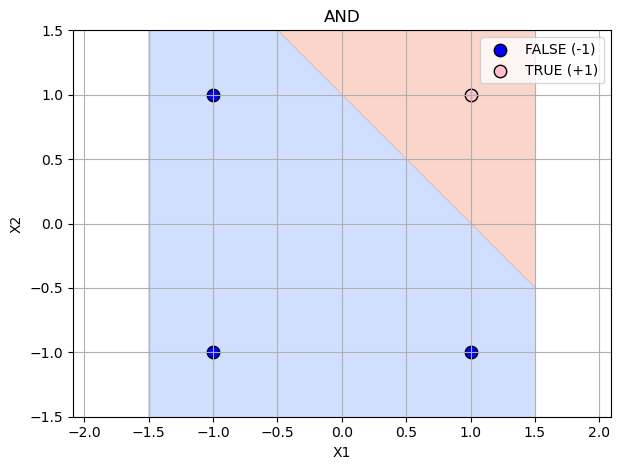

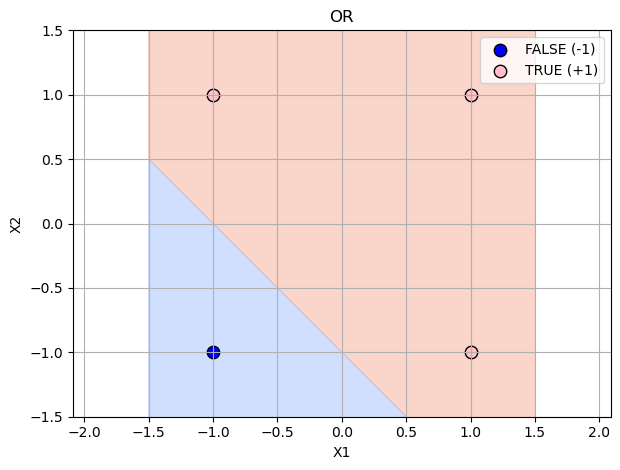

In [6]:
for sol, Xs, Ys, title in zip([sol_and, sol_or], [Xand, Xor], [Yand,Yor], ["AND", "OR"]):
    plot_mlp_decision_boundary(sol, Xs, Ys, title=title)

### Noisy input data
To consider a more realistic setting, let us suppose that the input has a noise, that is, for instance:
$$
    y = f_w(X + \epsilon)
$$
where $\epsilon \in \mathbb{R}^{n \times m}$ is any kind of noise coming from an unknown distribution (e.g., a uniform, normal, or lognormal).

The following function can be used to add noise to the input.

In [7]:
from numpy.random import normal
def AddNoise(X, mu=0.1):
    return list(map(lambda x: x+normal(0, mu), X))

In [8]:
# To increase the size of the input dataset:
T = 10
Xs = T*[AddNoise(X, 0.1) for X in Xand]
Ys = T*Yand
print(Xs[:5], Ys[:5])

[[-1.2580610592197743, -1.142675243297152], [-0.959881489442555, 1.0833066833779845], [0.9798232739718712, -1.078653990062226], [0.970273983686192, 0.84837415708343], [-1.2580610592197743, -1.142675243297152]] [-1, -1, -1, 1, -1]


**EXERCISE 1:** Adapt the previous script to be trained over random input data.

[[-0.968854067744372, -1.0520227018207646], [-0.9416912732121958, 1.285868674269217], [0.9190576278559002, -1.0009091022730081], [0.9055707865040367, 1.0957578345515893], [-0.968854067744372, -1.0520227018207646]] [-1, -1, -1, 1, -1]
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 160 rows, 83 columns and 480 nonzeros
Model fingerprint: 0x79dd0c4e
Variable types: 43 continuous, 40 integer (40 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+00]
Found heuristic solution: objective 20.0000000
Presolve removed 152 rows and 76 columns
Presolve time: 0.00s
Presolved: 8 rows, 7 columns, 32 nonzeros
Variable types: 3 continuous, 4 integer (4 binary)

Root r

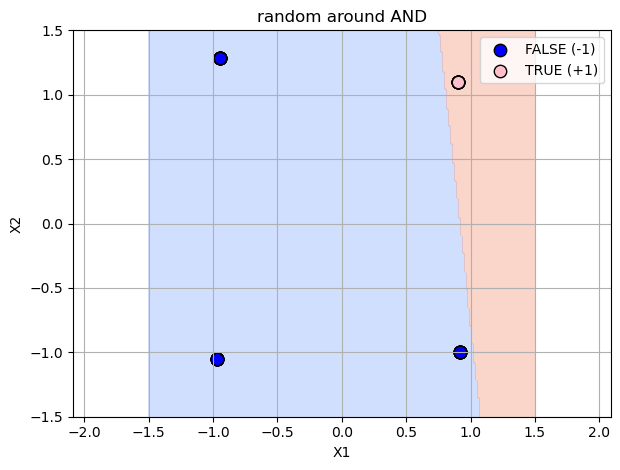

[[-1.0367217962110569, -1.0228688148422098], [-1.0948176611280764, 0.9865890547152811], [1.146537697297693, -0.8840487260869326], [1.138089290124388, 1.0857646891042996], [-1.0367217962110569, -1.0228688148422098]] [-1, -1, -1, 1, -1]
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 160 rows, 83 columns and 480 nonzeros
Model fingerprint: 0xaaf1ca9e
Variable types: 43 continuous, 40 integer (40 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+00]
Found heuristic solution: objective 20.0000000
Presolve removed 152 rows and 76 columns
Presolve time: 0.00s
Presolved: 8 rows, 7 columns, 32 nonzeros
Variable types: 3 continuous, 4 integer (4 binary)

Root 

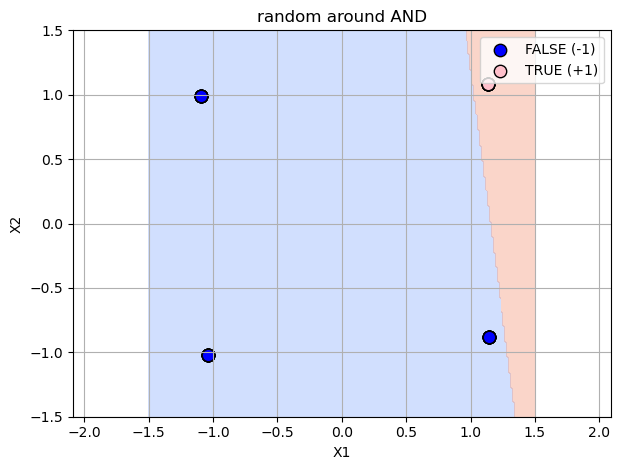

[[-0.9772807208969545, -1.0986998641651833], [-1.1085439800922365, 1.038218108493255], [0.8890511152316476, -1.0121416322362327], [0.937122450406419, 0.8758203648623022], [-0.9772807208969545, -1.0986998641651833]] [-1, -1, -1, 1, -1]
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 160 rows, 83 columns and 480 nonzeros
Model fingerprint: 0x94c26005
Variable types: 43 continuous, 40 integer (40 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+00]
Found heuristic solution: objective 20.0000000
Presolve removed 152 rows and 76 columns
Presolve time: 0.00s
Presolved: 8 rows, 7 columns, 32 nonzeros
Variable types: 3 continuous, 4 integer (4 binary)

Root 

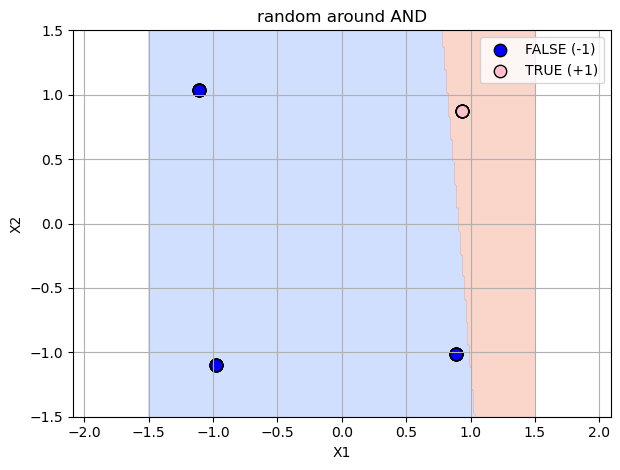

In [9]:
for _ in range(3):
    T = 10
    Xs = T*[AddNoise(X, 0.1) for X in Xand]
    Ys = T*Yand
    print(Xs[:5], Ys[:5])
    sol_random = LogicalNN(Xs, Ys, epsilon=0.1)
    plot_mlp_decision_boundary(sol_random, Xs, Ys, title = "random around AND")

## The **xor** logical function
The simple perceptron is unable to correctly learn the **xor** function because it is not linearly separable. One possibility to overcome this limitation is to change the structure of the parametric function $f_W$. (is W a matrix?)

For instance, we could use the following function, by adding a new vector of parameters U:
$$
    \hat{y} = f_{W,U} = \text{sign}(U \cdot \text{sign}(X W)) 
$$

Notice that now we have a *hidden* layer of unknows given by the inner $\text{sign}$ function. The inner product between the weight $U$ and the result of the sign function, introduce bilinear terms that must be carfully linearized, in order to use Integer Linear Programming to solve the training problem.

In [10]:
# XOR function
Xxor = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
Yxor = [-1, 1, 1, -1]

In [11]:
np.array([1, *Xxor[0]])

array([ 1, -1, -1])

In [12]:
np.array(Xxor)

array([[-1, -1],
       [-1,  1],
       [ 1, -1],
       [ 1,  1]])

In [13]:
def MLP(Xs, Ys, epsilon):
    # Main ILP model
    model = Model()
    # variabili W1, W2 
    W1 = {}
    W2 = {}
    n_points = len(Xs)
    dim = len(Xs[0])
    hidden_layer_dim =2
    M = 2
    # create the matrices
    for i in range(dim+1):
        for j in range(hidden_layer_dim):
            W1[i, j] = model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"W1_{i}_{j}")
    for j in range(hidden_layer_dim+1):
        W2[j] = model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"W2_{j}")

    sign_inner = {}
    z = {}
    for k in range(n_points):
        for j in range(hidden_layer_dim):
            p_k_j = quicksum((1 if i == 0 else Xs[k][i-1]) * W1[i, j] for i in range(dim+1))

            # devo calcolare il segno di p_k_j, lo penso come var binaria e poi lo converto in -1, 1
            sign_inner[k,j] = model.addVar(obj = 0, vtype= GRB.BINARY, name = f"sign_inner_{k}_{j}")
            
            model.addConstr(p_k_j >= epsilon-M*(1-sign_inner[k,j]), name = "sign = 1 then pkj >=0")
            model.addConstr(p_k_j <= -epsilon + M*sign_inner[k,j], name = "sign = 0 then pkj <= eps")
            

            # z[k,j] = model.addVar(lb = -1, ub = 1, vtype= GRB.INTEGER, obj = 0, name= f"z_{k}_{j}")
            # model.addConstr(z[k,j] == 2*sign_inner[k,j] - 1)

    # hidden layer: fatto! passo fuori
        # -------------------------------------------- 
    g = {}
    M = 2000
    for k in range(n_points):
        # devo modellizzare il prodotto
        for j in range(hidden_layer_dim+1):
            if j !=0:
                # gkj è il prodotto tra sign_inner e w2_k [senza il 0esimo]
                g[k,j] = model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"g_{k}_{j}")
                model.addConstr(g[k,j] <= M*sign_inner[k,j-1])
                model.addConstr(g[k,j] >= -M*sign_inner[k,j-1])
                model.addConstr(g[k,j] <= W2[j])
                model.addConstr(g[k,j] >= W2[j] + M*(sign_inner[k,j-1]-1))
        # g[k, 0] = W2[0]

    # qk = somma di g[k,j] al variare di j
    q = []
    for k in range(n_points):
        q.append(model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"q_{k}"))
        model.addConstr(q[k] == quicksum([2*g[k, j] - W2[j] for j in range(1, hidden_layer_dim+1) ]) + W2[0] )
    
    # devo fare il segno di qk
    sign_outer = []
    for k in range(n_points):
        sign_outer.append(model.addVar(obj=0, vtype= GRB.BINARY, name = f"sign_outer{k}")) 
        model.addConstr(q[k] >= epsilon - M*(1-sign_outer[k]))
        model.addConstr(q[k] <= - epsilon + M*sign_outer[k])


    val_abs = []
    for k in range(n_points):
        y_pred = 2 * sign_outer[k] - 1
        val_abs.append(model.addVar(lb = 0, ub = GRB.INFINITY, obj = 10, vtype=GRB.CONTINUOUS, name = f"val_abs{k}")) 
        model.addConstr(val_abs[k] >= y_pred-Ys[k])
        model.addConstr(val_abs[k] >= -y_pred + Ys[k])

    model.update()
    model.optimize()
    model.write("MLP.lp")



    if model.Status ==2:
        W1_sol = np.zeros((dim+1, hidden_layer_dim))
        W2_sol = np.zeros(hidden_layer_dim+1)

        for i in range(dim+1):
            for j in range(hidden_layer_dim):
                W1_sol[i,j] = W1[i, j].X 
        for j in range(hidden_layer_dim+1):
            W2_sol[j] = W2[j].X



        def sol_func(X):
            # print("W1:", W1_sol)
            # print("W2:", W2_sol)
            def hard_sign(x):
                return np.where(x >= 0, 1, -1)
            
            X = np.array(X)
            # print("Input:", X)
            if len(X.shape) != 1:
                X_ = np.hstack((np.ones((X.shape[0], 1)), np.array(X)))
                inner_out = hard_sign(X_ @ W1_sol)
                # print("Hidden layer output:", inner_out)
                out = np.hstack((np.ones((X.shape[0], 1)), inner_out)) @ W2_sol
                # print("Final raw output:", out)
                return hard_sign(out)
            else:
                X_ = np.array([1,  *X])
                inner_out = hard_sign(X_ @ W1_sol)
                # print("Hidden layer output:", inner_out)
                out = np.array([1, *inner_out]) @ W2_sol
                # print("Final raw output:", out)
                return hard_sign(out)
        return sol_func
        # def sol_func(X):
        #     print(X)
        #     def hard_sign(x):
        #         return np.where(x >= 0, 1, -1)
            
        #     X = np.array(X)
        #     if len(X.shape) != 1:
        #         X_ = np.hstack((np.ones((X.shape[0], 1)), np.array(X)))
        #         return hard_sign(np.hstack((np.ones((X.shape[0], 1)), hard_sign(X_@W1_sol)))@W2_sol)
        #     else:
        #         X_ = np.array([1,  *X])
        #         return hard_sign(np.array([1, *hard_sign(X_@W1_sol)])@W2_sol)
        # return sol_func
    else:
        print("Warning: something is wrong. The status of the model is:", model.Status)

Then, you have to design the validation test.

We could use the xor data:

In [14]:
# XOR function
Xxor = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
Yxor = [-1, 1, 1, -1]

In [15]:
sol_xor  = MLP(Xxor, Yxor, 0.1)

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 68 rows, 37 columns and 192 nonzeros
Model fingerprint: 0x8d1f0fd4
Variable types: 25 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+03]
Found heuristic solution: objective 40.0000000
Presolve removed 8 rows and 4 columns
Presolve time: 0.00s
Presolved: 60 rows, 33 columns, 176 nonzeros
Variable types: 21 continuous, 12 integer (12 binary)

Root relaxation: objective 0.000000e+00, 25 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time


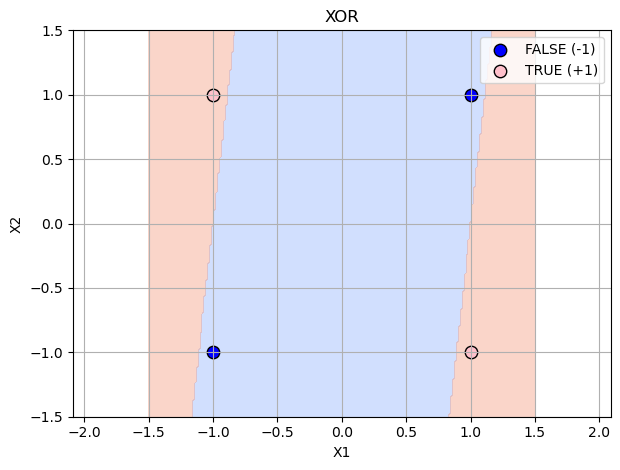

In [16]:
plot_mlp_decision_boundary(sol_xor, Xxor, Yxor, title = "XOR")


We could use the noisy data made before:

In [17]:
T = 10
Xs = T*np.array([AddNoise(X, 0.1) for X in Xxor])
Ys = T*Yxor
print(Xs[:5], Ys[:5])

[[ -9.87016159 -11.84919059]
 [-10.23397866  12.28041802]
 [ 11.96044784  -9.99193672]
 [ 10.6274222    9.65658325]] [-1, 1, 1, -1, -1]


And plot it... after we make the network work on it

In [18]:
sol_new = MLP(Xs, Ys, 0.1)


Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 68 rows, 37 columns and 192 nonzeros
Model fingerprint: 0x67d42a1c
Variable types: 25 continuous, 12 integer (12 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+03]
Found heuristic solution: objective 40.0000000
Presolve removed 8 rows and 4 columns
Presolve time: 0.00s
Presolved: 60 rows, 33 columns, 176 nonzeros
Variable types: 21 continuous, 12 integer (12 binary)

Root relaxation: objective 0.000000e+00, 24 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time


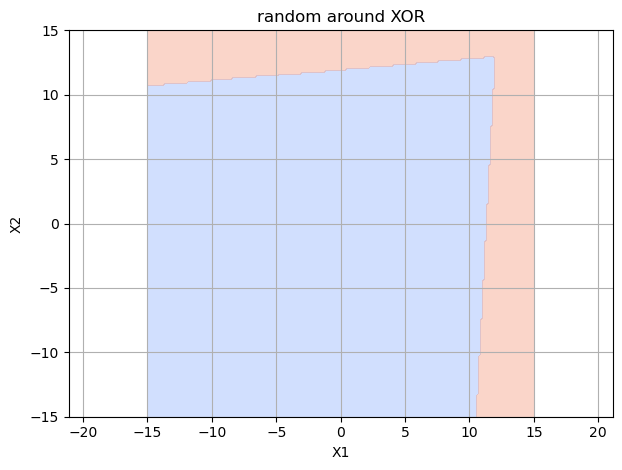

In [19]:

ranges = [(-15, 15), (-15, 15)]
plot_mlp_decision_boundary(sol_new,Xs, Ys, title = "random around XOR", random = True, ranges=ranges)

**EXERCISE 2:** Modify your script in such a way that the weight belong only to the set of values $\{-1, 0, +1\}$. Note that a value of 0 is equivalent to remove the corresponding link (and simplify the network).

In [ ]:
def MLP_integer(Xs, Ys, epsilon, max_hidden_layer = 100, return_weights = False):
    # Main ILP model
    model = Model()
    # variabili W1, W2 
    W1 = {}
    W2 = {}
    n_points = len(Xs)
    dim = len(Xs[0])
    hidden_layer_dim =max_hidden_layer
    M = 20
    # create the matrices
    for i in range(dim+1):
        for j in range(hidden_layer_dim):
            W1[i, j] = model.addVar(lb = -1, ub = 1, obj = 0, vtype= GRB.INTEGER, name = f"W1_{i}_{j}")
    for j in range(hidden_layer_dim+1):
        W2[j] = model.addVar(lb = -1, ub = 1, obj = 0, vtype= GRB.INTEGER, name = f"W2_{j}")

    sign_inner = {}
    z = {}
    for k in range(n_points):
        for j in range(hidden_layer_dim):
            p_k_j = quicksum((1 if i == 0 else Xs[k][i-1]) * W1[i, j] for i in range(dim+1))

            # devo calcolare il segno di p_k_j, lo penso come var binaria e poi lo converto in -1, 1
            sign_inner[k,j] = model.addVar(obj = 0, vtype= GRB.BINARY, name = f"sign_inner_{k}_{j}")
            
            model.addConstr(p_k_j >= epsilon-M*(1-sign_inner[k,j]), name = "sign = 1 then pkj >=0")
            model.addConstr(p_k_j <= -epsilon + M*sign_inner[k,j], name = "sign = 0 then pkj <= eps")
            

            # z[k,j] = model.addVar(lb = -1, ub = 1, vtype= GRB.INTEGER, obj = 0, name= f"z_{k}_{j}")
            # model.addConstr(z[k,j] == 2*sign_inner[k,j] - 1)

    # hidden layer: fatto! passo fuori
        # -------------------------------------------- 
    g = {}
    M = 2000
    for k in range(n_points):
        # devo modellizzare il prodotto
        for j in range(hidden_layer_dim+1):
            if j !=0:
                # gkj è il prodotto tra sign_inner e w2_k [senza il 0esimo]
                g[k,j] = model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"g_{k}_{j}")
                model.addConstr(g[k,j] <= M*sign_inner[k,j-1])
                model.addConstr(g[k,j] >= -M*sign_inner[k,j-1])
                model.addConstr(g[k,j] <= W2[j])
                model.addConstr(g[k,j] >= W2[j] + M*(sign_inner[k,j-1]-1))
        # g[k, 0] = W2[0]

    # qk = somma di g[k,j] al variare di j
    q = []
    for k in range(n_points):
        q.append(model.addVar(lb = -GRB.INFINITY, ub = GRB.INFINITY, obj = 0, vtype= GRB.CONTINUOUS, name = f"q_{k}"))
        model.addConstr(q[k] == quicksum([2*g[k, j] - W2[j] for j in range(1, hidden_layer_dim+1) ]) + W2[0] )
    
    # devo fare il segno di qk
    sign_outer = []
    for k in range(n_points):
        sign_outer.append(model.addVar(obj=0, vtype= GRB.BINARY, name = f"sign_outer{k}")) 
        model.addConstr(q[k] >= epsilon - M*(1-sign_outer[k]))
        model.addConstr(q[k] <= - epsilon + M*sign_outer[k])


    val_abs = []
    for k in range(n_points):
        y_pred = 2 * sign_outer[k] - 1
        val_abs.append(model.addVar(lb = 0, ub = GRB.INFINITY, obj = 10, vtype=GRB.CONTINUOUS, name = f"val_abs{k}")) 
        model.addConstr(val_abs[k] >= y_pred-Ys[k])
        model.addConstr(val_abs[k] >= -y_pred + Ys[k])

    model.update()
    model.optimize()
    model.write("MLP.lp")



    if model.Status ==2:
        W1_sol = np.zeros((dim+1, hidden_layer_dim))
        W2_sol = np.zeros(hidden_layer_dim+1)

        for i in range(dim+1):
            for j in range(hidden_layer_dim):
                W1_sol[i,j] = W1[i, j].X 
        for j in range(hidden_layer_dim+1):
            W2_sol[j] = W2[j].X



        def sol_func(X):
            print("W1:", W1_sol)
            print("W2:", W2_sol)
            def hard_sign(x):
                return np.where(x >= 0, 1, -1)
            
            X = np.array(X)
            # print("Input:", X)
            if len(X.shape) != 1:
                X_ = np.hstack((np.ones((X.shape[0], 1)), np.array(X)))
                inner_out = hard_sign(X_ @ W1_sol)
                # print("Hidden layer output:", inner_out)
                out = np.hstack((np.ones((X.shape[0], 1)), inner_out)) @ W2_sol
                # print("Final raw output:", out)
                return hard_sign(out)
            else:
                X_ = np.array([1,  *X])
                inner_out = hard_sign(X_ @ W1_sol)
                # print("Hidden layer output:", inner_out)
                out = np.array([1, *inner_out]) @ W2_sol
                # print("Final raw output:", out)
                return hard_sign(out)
        if return_weights:
            return sol_func, W1_sol, W2_sol
        else:
            return sol_func
       
    else:
        print("Warning: something is wrong. The status of the model is:", model.Status)

try with some data:

In [21]:
Xxor = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
Yxor = [-1, 1, 1, -1]

In [ ]:
sol_xor_binary = MLP_integer(Xxor, Yxor, 0.1, max_hidden_layer = 200)

Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i3-1005G1 CPU @ 1.20GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Optimize a model with 4820 rows, 2413 columns and 15240 nonzeros
Model fingerprint: 0x6b49eaa8
Variable types: 808 continuous, 1605 integer (804 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [1e+01, 1e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+03]
Presolve removed 7 rows and 3 columns
Presolve time: 0.09s
Presolved: 4813 rows, 2410 columns, 14626 nonzeros
Variable types: 804 continuous, 1606 integer (804 binary)
Found heuristic solution: objective 40.0000000

Root relaxation: objective 0.000000e+00, 3275 iterations, 0.13 seconds (0.10 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd

In [37]:
sol_xor_binary(Xxor)

W1: [[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1.  0. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
  -1. -1.]
 [-1.  1. -1.  0. -1.  0. -1. -1. -1.  0. -1. -1.  0. -1. -1.  0.  1. -1.
  -1. -1. -1.  1.  0. -1. -1.  0.  1. -1.  0.  0.  0.  0. -1.  0. -1. -1.
  -1. -1. -1.  0.  0.  

array([-1,  1,  1, -1])

W1: [[-1. -1.]
 [-1.  1.]
 [ 1. -1.]]
W2: [1. 1. 1.]


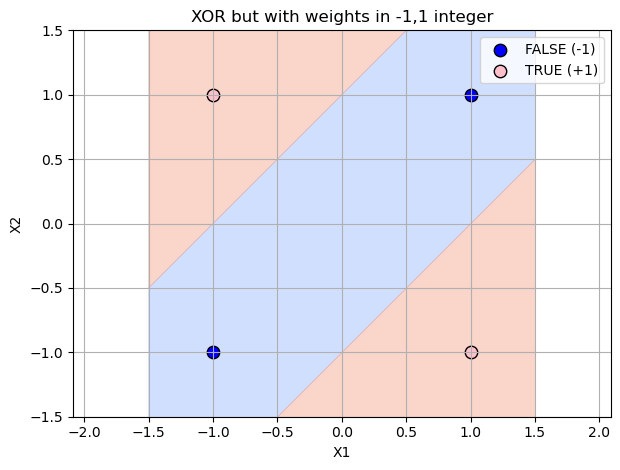

In [24]:
plot_mlp_decision_boundary(sol_xor_binary, Xxor, Yxor, title = "XOR but with weights in -1,1 integer")

**EXERCISE 3:** Can you *computationally proof* which is the smallest Binary Neural Network that can compute exactly the **xor** function? Hown many weights do you need in total?

(probabilmente devo solo vedere qual è il minimo max_hidden_layer_dim che fa funzionare bene le cose)

## Classification of MNIST digits
Starting from the solution used to model the **xor** function, you can build a parametric function whose parameters are fitted to classify images.

You can use the same structure used for the **xor** function, but by chaning the number of states in the hidden layer:
$$
    \hat{y} = f_{W,U} = \text{sign}(U \cdot \text{sign}(X W)) 
$$

Or you can propose any different type of solution.

You can download the dataset as follows.

In [ ]:
# Uncomment and exectue
# !wget https://mate.unipv.it/gualandi/opt4ds/all_three_four.csv

"wget" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [26]:
# Uncomment and exectue
# !wget https://mate.unipv.it/gualandi/opt4ds/all_nine_four.csv

## Parsing the dataset
To parse the dataset you can use the following function

In [1]:
import numpy as np
def Parse(filename):
    fh = open(filename, 'r')

    fh.readline()

    Xs, Ys = [], []
    for row in fh:
        line = row.replace('\n','').split(';')
        Ys.append(int(line[0]))
        Xs.append(list(map(int, line[1:])))

    return np.matrix(Xs), np.array(Ys)

In [2]:
Xs, Ys = Parse('../data/train_three_four.csv')

In [3]:
print('dimension of matrix X:', Xs.shape)

dimension of matrix X: (31, 784)


In [4]:
print('dimension of y:', Ys.shape)

dimension of y: (31,)


## Plotting digits
To plot a digit you can use the following snippet.

In [5]:
import matplotlib.pyplot as plt

def DrawDigit(A):
    plt.imshow(A.reshape((28, 28)), cmap='binary')
    plt.show()

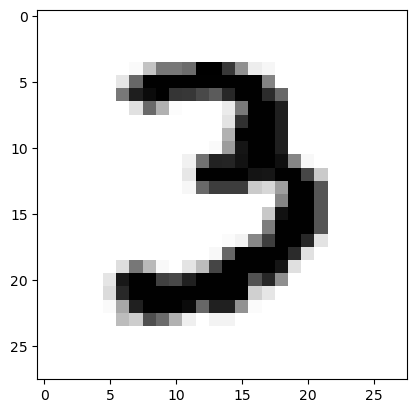

In [6]:
DrawDigit(Xs[2])

In [7]:
print(Ys[0], Ys[2])

4 3


In [10]:
Xs[0]

matrix([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0, 220, 179,   6,   0,   0,   0,   0,   0,   0,   0,
           0,   9,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,  28,

## Evaluating a NN
To evaluate the accuracy of a Binary NN you can run the following function.

In [8]:
def AccuracyMLP(Xs, Ys, F):
    y_hat = np.array([F(x) for x in Xs])

    n = len(Ys)
    return (np.sum(Ys == y_hat))/n*100

In [9]:
Ys

array([4, 3, 3, 3, 3, 3, 4, 3, 4, 4, 4, 3, 4, 3, 3, 4, 3, 4, 4, 4, 3, 4,
       4, 4, 4, 3, 3, 3, 4, 4, 4])

In [35]:
# nh = number of activation in the hidden layer
def TrainingMLP(Xs, Ys, nh=1):
    # Main ILP model
    model = Model()
    # TO COMPLETE with your model

    return lambda x: 1 - 2*randint(0,1)

# Number of internal states
nh = 2

# REMARK: the predict function
F = TrainingMLP(Xs, Ys, nh)

# Evaluate accuracy (be careful of the matrix dimension)
acc = AccuracyMLP(Xs, Ys, F)
print('accuracy:', round(acc, 2))

accuracy: 0.0


## BNN Classification Challenge
For this challenge, you have to design a binary neural network, that is a binary neural network where all weights are either +1 or -1, and that is able to solve a binary classification problem defined on pair of MNIST images.

For training, you will have two dataset, the first containing images of the digits 3 and 4, and the second, containing the images of digits 4 and 9. 

For the design phase, you should use a small number of input data points. Later, you can decide if having a *light* model that can take in input several data points, or a *heavy* model that can use only a few data points but is more general.

The evaluation will be carried over a hidden mixed dataset.

*REMARK*: You have to submit your solution by June, Thursday 11, 2025, sending an email containing your python solution script.

Partecipating to this (optional) challenge, you will get extra points for the final exam grade.